# Lag Depth Comparison Study — V3

## Pipeline
- **Phase 1** — Screen lag-1 to lag-5 with fixed [64,64], stride=1
- **Phase 2** — Optuna (15 trials) on every lag, retrain best trial, eval stride=1
- **Phase 3** — Comparison table: fixed vs tuned for every lag
- **Batches** — set N_BATCHES_SAMPLE to 5, 10, or 15; superset sampling ensures fair comparison


## 1. Imports

In [1]:
import os, time, random, warnings, json, pickle
from pathlib import Path

import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.preprocessing import StandardScaler

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings('ignore')


## 2. Reproducibility and device

In [2]:
SEED = 42

def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', DEVICE)


Using device: cpu


## 3. Configuration — only cell you need to edit between runs

In [3]:
# ============================================================
# USER CONFIGURATION
# ============================================================

BATCH_ROOT      = Path('/home/ma-stud/Downloads/Pierl_Test/simulink/input_batches')
N_BATCHES_TOTAL = 1000

# Change to 5, 10, or 15 for your three runs.
# The superset logic ensures each larger run contains all smaller run batches.
N_BATCHES_SAMPLE = 15    # <-- change this: 5 | 10 | 15

# Never change BATCH_SEED. It defines the fixed master list of 15 batches.
BATCH_SEED = 42

# Results are saved here. Rename before each run:
#   results_5batches  ->  results_10batches  ->  results_15batches
SAVE_DIR = Path('./results_15batches')   # <-- rename for each run

LAG_DEPTHS_TO_TEST = [1, 2, 3, 4, 5]   # lag-5 added

TRAIN_RATIO   = 0.8
HORIZON_STEPS = 30

# stride=1 everywhere for Phase 1 and final evaluation.
# TUNE_STRIDE=5 is used only inside Optuna proxy eval for speed.
EVAL_STRIDE  = 1   # Phase 1 fixed-arch evaluation
TUNE_STRIDE  = 5   # Optuna proxy (coarser = faster per trial)
FINAL_STRIDE = 1   # Final tuned model evaluation

FIXED_HIDDEN1 = 64
FIXED_HIDDEN2 = 64
FIXED_LR      = 1e-3
FIXED_WD      = 0.0

DEFAULT_EPOCHS          = 200
EARLY_STOPPING_PATIENCE = 15
DEFAULT_BATCH_SIZE      = 256
NUM_WORKERS             = 0

N_TRIALS          = 15    # Optuna trials per lag
TUNE_EPOCHS       = 100   # early stopping handles actual convergence
N_TUNE_VAL_ROASTS = 30    # small val subset for Optuna proxy

T_B_RANGE  = 300.0   # K
X_DB_RANGE = 1.0     # [-]

print(f'Batches        : {N_BATCHES_SAMPLE} of {N_BATCHES_TOTAL}')
print(f'Lag depths     : {LAG_DEPTHS_TO_TEST}')
print(f'EVAL_STRIDE    : {EVAL_STRIDE}  (Phase 1 and final)')
print(f'TUNE_STRIDE    : {TUNE_STRIDE}  (Optuna proxy only)')
print(f'N_TRIALS/lag   : {N_TRIALS}  |  TUNE_EPOCHS: {TUNE_EPOCHS}')
print(f'Save directory : {SAVE_DIR}')


Batches        : 15 of 1000
Lag depths     : [1, 2, 3, 4, 5]
EVAL_STRIDE    : 1  (Phase 1 and final)
TUNE_STRIDE    : 5  (Optuna proxy only)
N_TRIALS/lag   : 15  |  TUNE_EPOCHS: 100
Save directory : results_15batches


## 4. MATLAB HDF5 loading utilities

In [4]:
def resolve_matlab_field(f, group, field_name):
    obj = group[field_name]
    try:
        arr = np.array(obj)
    except Exception:
        arr = None
    if arr is not None and arr.dtype.kind in ('i','u','f'):
        return np.squeeze(arr)
    if arr is not None and arr.size == 1:
        ref = arr.reshape(-1)[0]
        try:
            return np.squeeze(np.array(f[ref]))
        except Exception:
            pass
    try:
        ref = obj[0, 0]
        return np.squeeze(np.array(f[ref]))
    except Exception:
        pass
    raise ValueError(f"Could not resolve field '{field_name}'")


def safe_constant_value(x, name='value'):
    x = np.array(x).squeeze()
    if x.shape == ():  return float(x)
    if x.size == 1:    return float(x.reshape(-1)[0])
    flat = x.reshape(-1)
    if np.allclose(flat, flat[0], rtol=1e-6, atol=1e-8): return float(flat[0])
    raise ValueError(f'Expected scalar-like {name}, got shape {x.shape}')


def load_one_roast(mat_path, idx):
    with h5py.File(mat_path, 'r') as f:
        io_ref = f['inputs_and_outputs'][0, idx]
        oo_ref = f['inputs_and_outputs'][1, idx]
        in_g, out_g = f[io_ref], f[oo_ref]
        Time  = resolve_matlab_field(f, in_g,  'Time').astype(np.float32)
        T_g   = resolve_matlab_field(f, in_g,  'T_gi').astype(np.float32)
        m_dot = resolve_matlab_field(f, in_g,  'm_dot').astype(np.float32)
        T_b   = resolve_matlab_field(f, out_g, 'T_b').astype(np.float32)
        X_db  = resolve_matlab_field(f, out_g, 'X_db').astype(np.float32)
        m_b0  = safe_constant_value(resolve_matlab_field(f, in_g, 'm_b0'),  name='m_b0')
        d_b0  = safe_constant_value(resolve_matlab_field(f, in_g, 'd_b0'),  name='d_b0')
        X_b0  = safe_constant_value(resolve_matlab_field(f, in_g, 'X_0db'), name='X_0db')
    n = min(len(Time), len(T_g), len(m_dot), len(T_b), len(X_db))
    return {
        'Time': Time[:n], 'T_g': T_g[:n], 'm_dot': m_dot[:n],
        'T_b':  T_b[:n],  'X_db': X_db[:n],
        'm_b0': np.float32(m_b0), 'd_b0': np.float32(d_b0), 'X_b0': np.float32(X_b0),
    }


def get_num_roasts(mat_path):
    with h5py.File(mat_path, 'r') as f:
        return f['inputs_and_outputs'].shape[1]


## 5. Batch file selection — superset sampling

**Why superset?** We run the pipeline with 5, 10, and 15 batches to study the effect of data quantity. If each run picked a completely independent random set, differences could come from *which* batches were chosen, not from having *more* data.

**The fix:** pick a master ordered list of 15 batches once (BATCH_SEED=42, never change). The 5-batch run uses positions 0-4, the 10-batch run uses 0-9, the 15-batch run uses all 15. Every larger run is a strict superset of the smaller run. Only `N_BATCHES_SAMPLE` and `SAVE_DIR` need to change between runs.


In [5]:
def get_all_batch_paths(batch_root, n_total):
    paths = []
    for i in range(1, n_total + 1):
        p = batch_root / f'input_batch_{i}.mat'
        if p.exists():
            paths.append(p)
    return paths


def get_superset_batch_paths(batch_root, n_total, master_n, n_use, seed):
    """
    Selects n_use batches from a fixed master list of master_n batches.
    The master list is always built with the same seed, so:
      n_use=5  -> first 5 of master list
      n_use=10 -> first 10 of master list (includes the 5)
      n_use=15 -> all 15 of master list
    """
    all_paths = get_all_batch_paths(batch_root, n_total)
    if not all_paths:
        raise FileNotFoundError(f'No batch files found in {batch_root}')
    master_n = min(master_n, len(all_paths))
    rng = np.random.default_rng(seed)
    master_idx = sorted(rng.choice(len(all_paths), size=master_n, replace=False))
    master_list = [all_paths[i] for i in master_idx]
    if n_use > len(master_list):
        print(f'WARNING: n_use={n_use} > master_n={len(master_list)}, using all.')
        n_use = len(master_list)
    chosen = master_list[:n_use]
    print(f'Master pool : {len(master_list)} batches (BATCH_SEED={seed}, fixed)')
    print(f'Using first : {n_use} batches for this run')
    for p in chosen:
        print(f'  {p.name}')
    return chosen


def build_roast_index(batch_paths):
    roast_index, gid = [], 0
    for path in batch_paths:
        n = get_num_roasts(path)
        print(f'  {path.name}: {n} roasts')
        for local_idx in range(n):
            roast_index.append((gid, str(path), local_idx))
            gid += 1
    print(f'Total roasts: {len(roast_index)}')
    return roast_index


# Master pool size is always 15 (the maximum you will ever use).
# First N_BATCHES_SAMPLE entries are used for this run.
MASTER_N    = 15
BATCH_PATHS = get_superset_batch_paths(
    BATCH_ROOT, N_BATCHES_TOTAL,
    master_n=MASTER_N, n_use=N_BATCHES_SAMPLE, seed=BATCH_SEED)

roast_index = build_roast_index(BATCH_PATHS)


Master pool : 15 batches (BATCH_SEED=42, fixed)
Using first : 15 batches for this run
  input_batch_86.mat
  input_batch_89.mat
  input_batch_94.mat
  input_batch_201.mat
  input_batch_429.mat
  input_batch_435.mat
  input_batch_525.mat
  input_batch_647.mat
  input_batch_693.mat
  input_batch_718.mat
  input_batch_735.mat
  input_batch_761.mat
  input_batch_764.mat
  input_batch_851.mat
  input_batch_973.mat
  input_batch_86.mat: 937 roasts
  input_batch_89.mat: 957 roasts
  input_batch_94.mat: 943 roasts
  input_batch_201.mat: 949 roasts
  input_batch_429.mat: 945 roasts
  input_batch_435.mat: 952 roasts
  input_batch_525.mat: 948 roasts
  input_batch_647.mat: 943 roasts
  input_batch_693.mat: 955 roasts
  input_batch_718.mat: 943 roasts
  input_batch_735.mat: 956 roasts
  input_batch_761.mat: 946 roasts
  input_batch_764.mat: 944 roasts
  input_batch_851.mat: 943 roasts
  input_batch_973.mat: 957 roasts
Total roasts: 14218


## 6. Roast-level train/validation split

In [6]:
def roast_level_split(roast_index, train_ratio=0.8, seed=42):
    ids = list(range(len(roast_index)))
    rng = np.random.default_rng(seed)
    rng.shuffle(ids)
    n_train = int(len(ids) * train_ratio)
    train_roasts = [roast_index[i] for i in sorted(ids[:n_train])]
    val_roasts   = [roast_index[i] for i in sorted(ids[n_train:])]
    return train_roasts, val_roasts


train_roasts, val_roasts = roast_level_split(roast_index, TRAIN_RATIO, SEED)

rng = np.random.default_rng(SEED)
subset_idx = rng.choice(len(val_roasts),
                        size=min(N_TUNE_VAL_ROASTS, len(val_roasts)),
                        replace=False)
val_roasts_tune = [val_roasts[i] for i in sorted(subset_idx)]

print(f'Train roasts      : {len(train_roasts)}')
print(f'Val roasts        : {len(val_roasts)}')
print(f'Val subset Optuna : {len(val_roasts_tune)}')


Train roasts      : 11374
Val roasts        : 2844
Val subset Optuna : 30


## 7. Lag feature builder (supports any n_lags)

Feature layout: `[T_g(t), m_dot(t), m_b0, X_b0, d_b0, T_b(t), X_db(t), T_b(t-1), X_db(t-1), ...]`  
Input dim = 5 + 2*(n_lags + 1)


In [7]:
def input_dim_for_lag(n_lags):
    return 5 + 2 * (n_lags + 1)


def build_lagged_pairs(roast, n_lags=1):
    T_g, m_dot = roast['T_g'], roast['m_dot']
    T_b, X_db  = roast['T_b'], roast['X_db']
    m_b0, X_b0, d_b0 = roast['m_b0'], roast['X_b0'], roast['d_b0']
    L = len(T_g)
    if L < n_lags + 2:
        return (np.empty((0, input_dim_for_lag(n_lags)), dtype=np.float32),
                np.empty((0, 2), dtype=np.float32))
    t_range = np.arange(n_lags, L - 1)
    n = len(t_range)
    X = np.zeros((n, input_dim_for_lag(n_lags)), dtype=np.float32)
    Y = np.zeros((n, 2), dtype=np.float32)
    X[:, 0] = T_g[t_range];  X[:, 1] = m_dot[t_range]
    X[:, 2] = m_b0;           X[:, 3] = X_b0;  X[:, 4] = d_b0
    X[:, 5] = T_b[t_range];   X[:, 6] = X_db[t_range]
    for lag in range(1, n_lags + 1):
        X[:, 5 + 2*lag] = T_b[t_range - lag]
        X[:, 6 + 2*lag] = X_db[t_range - lag]
    Y[:, 0] = T_b[t_range + 1]
    Y[:, 1] = X_db[t_range + 1]
    return X, Y


for lag in LAG_DEPTHS_TO_TEST:
    print(f'  lag-{lag}: input_dim = {input_dim_for_lag(lag)}')


  lag-1: input_dim = 9
  lag-2: input_dim = 11
  lag-3: input_dim = 13
  lag-4: input_dim = 15
  lag-5: input_dim = 17


## 8. Dataset, model, and training utilities

In [8]:
def build_dataset(roast_list, n_lags):
    X_all, Y_all = [], []
    for _, mat_path, local_idx in roast_list:
        roast = load_one_roast(mat_path, local_idx)
        X, Y  = build_lagged_pairs(roast, n_lags=n_lags)
        if len(X) == 0: continue
        X_all.append(X); Y_all.append(Y)
    if not X_all:
        raise ValueError('No valid roasts found.')
    return np.vstack(X_all), np.vstack(Y_all)


class RoastDataset(Dataset):
    def __init__(self, X, Y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.Y = torch.tensor(Y, dtype=torch.float32)
    def __len__(self):          return len(self.X)
    def __getitem__(self, idx): return self.X[idx], self.Y[idx]


class LaggedMLP(nn.Module):
    def __init__(self, input_dim, hidden1=64, hidden2=64, output_dim=2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden1), nn.ReLU(),
            nn.Linear(hidden1, hidden2),   nn.ReLU(),
            nn.Linear(hidden2, output_dim)
        )
    def forward(self, x): return self.net(x)


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total, n = 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(model(xb), yb)
        loss.backward(); optimizer.step()
        total += loss.item() * xb.size(0); n += xb.size(0)
    return total / n


def eval_one_epoch(model, loader, criterion, device):
    model.eval()
    total, n = 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            loss = criterion(model(xb), yb)
            total += loss.item() * xb.size(0); n += xb.size(0)
    return total / n


def fit_model(model, train_loader, val_loader,
              lr=1e-3, weight_decay=0.0, epochs=100, patience=15,
              device='cpu', verbose=True):
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    history = {'train_loss': [], 'val_loss': []}
    best_state, best_val, no_improve = None, np.inf, 0
    for epoch in range(1, epochs + 1):
        tl = train_one_epoch(model, train_loader, optimizer, criterion, device)
        vl = eval_one_epoch(model, val_loader, criterion, device)
        history['train_loss'].append(tl)
        history['val_loss'].append(vl)
        improved = vl < best_val
        if improved:
            best_val   = vl
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            no_improve = 0
        else:
            no_improve += 1
        if verbose:
            print(f'Epoch {epoch:03d} | Train: {tl:.6f} | Val: {vl:.6f}' +
                  (' *' if improved else ''))
        if no_improve >= patience:
            if verbose: print(f'Early stopping at epoch {epoch}.')
            break
    if best_state: model.load_state_dict(best_state)
    return model, history, best_val


## 9. MPC evaluator — batched (replaces per-step loop)

`predict_one_step` is kept only for the inference-time benchmark.  
All MPC evaluation uses `mpc_eval_one_roast_batched`, which processes  
all W starting windows in parallel at each horizon step.  
This reduces ~14M individual forward passes to 30 batched passes per roast —  
typically **20–50x faster** on CPU.


In [9]:
def predict_one_step(model, x_scaler, y_scaler, feat_vec, device):
    """Single-step inference — kept for inference time benchmarking only."""
    model.eval()
    x_s = x_scaler.transform(feat_vec.reshape(1, -1)).astype(np.float32)
    with torch.no_grad():
        y_s = model(torch.tensor(x_s, device=device)).cpu().numpy()
    return y_scaler.inverse_transform(y_s)[0].astype(np.float32)


def mpc_eval_one_roast_batched(model, x_sc, y_sc, roast,
                                n_lags, horizon_steps=30, stride=1, device='cpu'):
    """
    Batched MPC evaluation for one roast.

    Key speedup over the original loop-based version:
    - All W starting windows are processed IN PARALLEL at each horizon step.
    - The outer loop over windows collapses: only `horizon_steps` (30) forward
      passes are made instead of W*horizon_steps (~24,000 on a typical roast).
    - Each forward pass processes W samples simultaneously as a matrix.
    - On CPU this is typically 20-50x faster than the sequential version.

    The inner loop (30 steps) must stay sequential because step k+1
    depends on the prediction from step k (autoregressive rollout).
    """
    T_g       = roast['T_g']
    m_dot     = roast['m_dot']
    T_b_true  = roast['T_b']
    X_db_true = roast['X_db']
    m_b0, X_b0, d_b0 = roast['m_b0'], roast['X_b0'], roast['d_b0']
    L = len(T_g)

    start_t = n_lags
    end_t   = L - horizon_steps - 1

    empty = {
        'horizon_abs_Tb': np.empty((0, horizon_steps), dtype=np.float32),
        'horizon_abs_X':  np.empty((0, horizon_steps), dtype=np.float32),
        'horizon_rel_Tb': np.empty((0, horizon_steps), dtype=np.float32),
        'horizon_rel_X':  np.empty((0, horizon_steps), dtype=np.float32),
        'window_mae_Tb':  np.empty(0, dtype=np.float32),
        'window_mae_X':   np.empty(0, dtype=np.float32),
        'window_rel_Tb':  np.empty(0, dtype=np.float32),
        'window_rel_X':   np.empty(0, dtype=np.float32),
        'window_maxabs_Tb': np.empty(0, dtype=np.float32),
        'window_maxabs_X':  np.empty(0, dtype=np.float32),
    }
    if end_t < start_t:
        return empty

    t0_arr = np.arange(start_t, end_t + 1, stride)  # all starting positions
    W = len(t0_arr)                                   # number of windows
    dim = input_dim_for_lag(n_lags)

    # --- Initialise lag buffers for ALL windows simultaneously ---
    # Tb_buf[w, 0] = T_b at t0_arr[w],  Tb_buf[w, 1] = T_b at t0_arr[w]-1, ...
    Tb_buf = np.stack(
        [T_b_true[t0_arr - k] for k in range(n_lags + 1)], axis=1
    ).astype(np.float32)   # shape (W, n_lags+1)
    X_buf = np.stack(
        [X_db_true[t0_arr - k] for k in range(n_lags + 1)], axis=1
    ).astype(np.float32)   # shape (W, n_lags+1)

    all_pred_Tb = np.zeros((W, horizon_steps), dtype=np.float32)
    all_pred_X  = np.zeros((W, horizon_steps), dtype=np.float32)

    model.eval()
    for k in range(horizon_steps):   # only 30 iterations total per roast
        tk_arr = t0_arr + k          # current timestep for each window

        # Build feature matrix for ALL W windows at once
        feat = np.zeros((W, dim), dtype=np.float32)
        feat[:, 0] = T_g[tk_arr]
        feat[:, 1] = m_dot[tk_arr]
        feat[:, 2] = m_b0
        feat[:, 3] = X_b0
        feat[:, 4] = d_b0
        for lag in range(n_lags + 1):
            feat[:, 5 + 2*lag] = Tb_buf[:, lag]
            feat[:, 6 + 2*lag] = X_buf[:, lag]

        # Single batched forward pass (W samples at once)
        feat_s = x_sc.transform(feat).astype(np.float32)
        with torch.no_grad():
            preds_s = model(
                torch.tensor(feat_s, device=device)
            ).cpu().numpy()          # shape (W, 2)
        preds = y_sc.inverse_transform(preds_s)  # shape (W, 2)

        pTb = preds[:, 0]   # shape (W,)
        pX  = preds[:, 1]

        all_pred_Tb[:, k] = pTb
        all_pred_X[:, k]  = pX

        # Roll lag buffers: shift right, insert new prediction at position 0
        Tb_buf = np.roll(Tb_buf, shift=1, axis=1)
        Tb_buf[:, 0] = pTb
        X_buf  = np.roll(X_buf,  shift=1, axis=1)
        X_buf[:, 0]  = pX

    # --- Ground truth sequences for all windows ---
    # true_Tb[w, :] = T_b_true[t0_arr[w]+1 : t0_arr[w]+1+horizon_steps]
    true_Tb = np.stack(
        [T_b_true[t0+1 : t0+1+horizon_steps]  for t0 in t0_arr]
    ).astype(np.float32)   # shape (W, horizon_steps)
    true_X = np.stack(
        [X_db_true[t0+1 : t0+1+horizon_steps] for t0 in t0_arr]
    ).astype(np.float32)

    abs_Tb = np.abs(all_pred_Tb - true_Tb)          # (W, 30)
    abs_X  = np.abs(all_pred_X  - true_X)
    rel_Tb = abs_Tb / T_B_RANGE  * 100              # percent
    rel_X  = abs_X  / X_DB_RANGE * 100

    return {
        'horizon_abs_Tb':   abs_Tb,
        'horizon_abs_X':    abs_X,
        'horizon_rel_Tb':   rel_Tb,
        'horizon_rel_X':    rel_X,
        'window_mae_Tb':    np.mean(abs_Tb, axis=1),
        'window_mae_X':     np.mean(abs_X,  axis=1),
        'window_rel_Tb':    np.mean(rel_Tb, axis=1),
        'window_rel_X':     np.mean(rel_X,  axis=1),
        'window_maxabs_Tb': np.max(abs_Tb,  axis=1),
        'window_maxabs_X':  np.max(abs_X,   axis=1),
    }


def aggregate_mpc_eval(model, x_sc, y_sc, roast_list,
                        n_lags, horizon_steps=30, stride=1, device='cpu'):
    """
    Runs mpc_eval_one_roast_batched across all roasts and stacks results.
    Returns arrays of shape (total_windows, horizon_steps) for horizon metrics
    and (total_windows,) for per-window scalars.
    """
    keys_2d = ['horizon_abs_Tb','horizon_abs_X','horizon_rel_Tb','horizon_rel_X']
    keys_1d = ['window_mae_Tb','window_mae_X','window_rel_Tb','window_rel_X',
               'window_maxabs_Tb','window_maxabs_X']
    parts_2d = {k: [] for k in keys_2d}
    parts_1d = {k: [] for k in keys_1d}

    for _, mat_path, local_idx in roast_list:
        roast  = load_one_roast(mat_path, local_idx)
        result = mpc_eval_one_roast_batched(
            model, x_sc, y_sc, roast,
            n_lags=n_lags, horizon_steps=horizon_steps,
            stride=stride, device=device)
        if result['window_mae_Tb'].size == 0:
            continue
        for k in keys_2d: parts_2d[k].append(result[k])
        for k in keys_1d: parts_1d[k].append(result[k])

    agg = {}
    for k in keys_2d:
        agg[k] = np.vstack(parts_2d[k]) if parts_2d[k] else \
                 np.empty((0, horizon_steps), dtype=np.float32)
    for k in keys_1d:
        agg[k] = np.concatenate(parts_1d[k]) if parts_1d[k] else \
                 np.empty(0, dtype=np.float32)
    return agg


def print_mpc_summary(agg, label='Model'):
    n = len(agg['window_mae_Tb'])
    print(f'\n===== {label} =====')
    print(f'  Windows : {n:,}')
    print(f"  T_b  | MAE: {np.mean(agg['window_mae_Tb']):.4f} K"
          f"  | Rel mean: {np.mean(agg['window_rel_Tb']):.3f}%"
          f"  | Rel p90: {np.percentile(agg['window_rel_Tb'],90):.3f}%"
          f"  | MaxAbs: {np.mean(agg['window_maxabs_Tb']):.4f} K")
    print(f"  X_db | MAE: {np.mean(agg['window_mae_X']):.6f}"
          f"  | Rel mean: {np.mean(agg['window_rel_X']):.3f}%"
          f"  | Rel p90: {np.percentile(agg['window_rel_X'],90):.3f}%"
          f"  | MaxAbs: {np.mean(agg['window_maxabs_X']):.6f}")


def metrics_dict(agg, stride):
    """Extract scalar summary metrics from an aggregated MPC result."""
    return {
        'n_windows':       int(len(agg['window_mae_Tb'])),
        'eval_stride':     stride,
        'rel_Tb_mean_%':   round(float(np.mean(agg['window_rel_Tb'])), 4),
        'rel_X_mean_%':    round(float(np.mean(agg['window_rel_X'])),  4),
        'rel_Tb_p90_%':    round(float(np.percentile(agg['window_rel_Tb'], 90)), 4),
        'rel_X_p90_%':     round(float(np.percentile(agg['window_rel_X'],  90)), 4),
        'mae_Tb_mean_K':   round(float(np.mean(agg['window_mae_Tb'])),    4),
        'mae_X_mean':      round(float(np.mean(agg['window_mae_X'])),     6),
        'rel_Tb_at_1s_%':  round(float(np.mean(agg['horizon_rel_Tb'][:, 0])),   4),
        'rel_Tb_at_30s_%': round(float(np.mean(agg['horizon_rel_Tb'][:, -1])),  4),
    }


## 10. Phase 1 — Fixed [64,64] screening, lag-1 to lag-5, stride=1

Trains all five lag depths with the same fixed architecture and evaluates at stride=1.
Goal: see which lags are worth tuning. Lag-1 is always the reference benchmark.


In [10]:
phase1_results = {}

for n_lags in LAG_DEPTHS_TO_TEST:
    print(f"\n{'='*60}")
    print(f'  LAG-{n_lags}  |  input_dim={input_dim_for_lag(n_lags)}')
    print(f"{'='*60}")

    X_tr_raw, Y_tr_raw = build_dataset(train_roasts, n_lags)
    X_va_raw, Y_va_raw = build_dataset(val_roasts,   n_lags)

    x_sc = StandardScaler().fit(X_tr_raw)
    y_sc = StandardScaler().fit(Y_tr_raw)
    X_tr = x_sc.transform(X_tr_raw).astype(np.float32)
    Y_tr = y_sc.transform(Y_tr_raw).astype(np.float32)
    X_va = x_sc.transform(X_va_raw).astype(np.float32)
    Y_va = y_sc.transform(Y_va_raw).astype(np.float32)

    print(f'  Dataset: train={X_tr.shape[0]:,} | val={X_va.shape[0]:,}')

    tr_loader = DataLoader(RoastDataset(X_tr, Y_tr),
                           batch_size=DEFAULT_BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS)
    va_loader = DataLoader(RoastDataset(X_va, Y_va),
                           batch_size=DEFAULT_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    set_seed(SEED)
    model = LaggedMLP(input_dim=input_dim_for_lag(n_lags),
                      hidden1=FIXED_HIDDEN1, hidden2=FIXED_HIDDEN2).to(DEVICE)

    t0 = time.time()
    model, history, best_val = fit_model(
        model, tr_loader, va_loader,
        lr=FIXED_LR, weight_decay=FIXED_WD,
        epochs=DEFAULT_EPOCHS, patience=EARLY_STOPPING_PATIENCE,
        device=DEVICE, verbose=False)
    train_time = time.time() - t0
    epochs_run = len(history['train_loss'])
    print(f'  Trained {epochs_run} epochs in {train_time:.1f}s | best val: {best_val:.6f}')

    dummy = np.zeros(input_dim_for_lag(n_lags), dtype=np.float32)
    t_inf = time.time()
    for _ in range(1000): predict_one_step(model, x_sc, y_sc, dummy, DEVICE)
    inf_us = (time.time() - t_inf) / 1000 * 1e6

    print(f'  MPC eval (stride={EVAL_STRIDE})...')
    t_eval = time.time()
    mpc_agg = aggregate_mpc_eval(
        model, x_sc, y_sc, val_roasts,
        n_lags=n_lags, horizon_steps=HORIZON_STEPS,
        stride=EVAL_STRIDE, device=DEVICE)
    eval_time = time.time() - t_eval
    print(f"  {len(mpc_agg['window_mae_Tb']):,} windows in {eval_time:.1f}s")

    print_mpc_summary(mpc_agg, label=f'Lag-{n_lags} [64,64]')

    phase1_results[n_lags] = {
        'n_lags': n_lags, 'input_dim': input_dim_for_lag(n_lags),
        'architecture': '[64,64]',
        'epochs_run': epochs_run, 'train_time_s': round(train_time,1),
        'inference_us': round(inf_us,2),
        **metrics_dict(mpc_agg, EVAL_STRIDE),
        '_model': model, '_x_sc': x_sc, '_y_sc': y_sc,
        '_history': history, '_mpc_agg': mpc_agg,
    }

print('\nPhase 1 complete.')



  LAG-1  |  input_dim=9
  Dataset: train=6,220,886 | val=1,544,237
  Trained 39 epochs in 881.7s | best val: 0.000184
  MPC eval (stride=1)...
  1,461,761 windows in 16.9s

===== Lag-1 [64,64] =====
  Windows : 1,461,761
  T_b  | MAE: 1.3589 K  | Rel mean: 0.453%  | Rel p90: 0.893%  | MaxAbs: 3.0299 K
  X_db | MAE: 0.001902  | Rel mean: 0.190%  | Rel p90: 0.398%  | MaxAbs: 0.003618

  LAG-2  |  input_dim=11
  Dataset: train=6,209,512 | val=1,541,393
  Trained 113 epochs in 2523.9s | best val: 0.000166
  MPC eval (stride=1)...
  1,458,917 windows in 16.6s

===== Lag-2 [64,64] =====
  Windows : 1,458,917
  T_b  | MAE: 2.0552 K  | Rel mean: 0.685%  | Rel p90: 1.389%  | MaxAbs: 4.5089 K
  X_db | MAE: 0.005906  | Rel mean: 0.591%  | Rel p90: 1.265%  | MaxAbs: 0.011648

  LAG-3  |  input_dim=13
  Dataset: train=6,198,138 | val=1,538,549
  Trained 152 epochs in 3829.2s | best val: 0.000091
  MPC eval (stride=1)...
  1,456,073 windows in 19.1s

===== Lag-3 [64,64] =====
  Windows : 1,456,073


## 11. Phase 1 — Comparison table

In [11]:
p1_cols = ['n_lags','input_dim','architecture','train_time_s','inference_us','epochs_run',
           'rel_Tb_mean_%','rel_X_mean_%','rel_Tb_p90_%','rel_X_p90_%',
           'mae_Tb_mean_K','mae_X_mean','rel_Tb_at_1s_%','rel_Tb_at_30s_%']

p1_rows = [{c: phase1_results[lag].get(c, lag) for c in p1_cols}
           for lag in LAG_DEPTHS_TO_TEST]
df_phase1 = pd.DataFrame(p1_rows).set_index('n_lags')

print('\n===== PHASE 1: Fixed [64,64] — stride=1 =====')
print(df_phase1.to_string())

best_lag_p1 = int(df_phase1['rel_Tb_mean_%'].idxmin())
print(f'\nBest lag (Phase 1, fixed arch): lag-{best_lag_p1}')



===== PHASE 1: Fixed [64,64] — stride=1 =====
        input_dim architecture  train_time_s  inference_us  epochs_run  rel_Tb_mean_%  rel_X_mean_%  rel_Tb_p90_%  rel_X_p90_%  mae_Tb_mean_K  mae_X_mean  rel_Tb_at_1s_%  rel_Tb_at_30s_%
n_lags                                                                                                                                                                                    
1               9      [64,64]         881.7         75.10          39         0.4530        0.1902        0.8928       0.3981         1.3589    0.001902          0.0642           0.7393
2              11      [64,64]        2523.9         72.75         113         0.6851        0.5906        1.3891       1.2652         2.0552    0.005906          0.0630           1.2874
3              13      [64,64]        3829.2         79.94         152         0.7630        0.8316        1.4522       1.8494         2.2889    0.008316          0.0519           1.4680
4              15 

## 12. Phase 1 — Horizon-wise error growth (all lags)

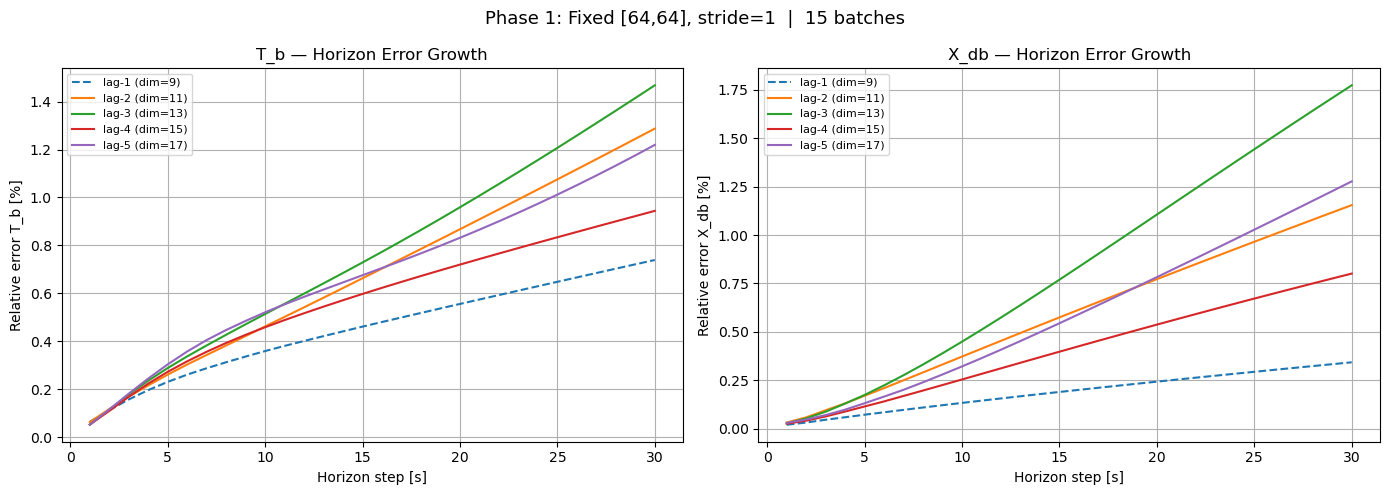

In [12]:
steps = np.arange(1, HORIZON_STEPS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for n_lags in LAG_DEPTHS_TO_TEST:
    agg   = phase1_results[n_lags]['_mpc_agg']
    label = f'lag-{n_lags} (dim={input_dim_for_lag(n_lags)})'
    ls    = '--' if n_lags == 1 else '-'
    axes[0].plot(steps, np.mean(agg['horizon_rel_Tb'], axis=0), label=label, linestyle=ls)
    axes[1].plot(steps, np.mean(agg['horizon_rel_X'],  axis=0), label=label, linestyle=ls)

for ax, ylabel, title in zip(axes,
    ['Relative error T_b [%]', 'Relative error X_db [%]'],
    ['T_b — Horizon Error Growth', 'X_db — Horizon Error Growth']):
    ax.set_xlabel('Horizon step [s]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True)

plt.suptitle(f'Phase 1: Fixed [64,64], stride=1  |  {N_BATCHES_SAMPLE} batches', fontsize=13)
plt.tight_layout()
plt.show()


## 13. Phase 2 — Optuna tuning for every lag depth

For each lag (1-5):
1. Run 15 Optuna trials using proxy eval (30 val roasts, TUNE_STRIDE=5)
2. Retrain the single best trial with DEFAULT_EPOCHS=100 and early stopping
3. Evaluate at FINAL_STRIDE=1 on the full validation set

Result: one fully-tuned model per lag depth.


In [13]:
phase2_results = {}

for n_lags in LAG_DEPTHS_TO_TEST:
    print(f"\n{'='*60}")
    print(f'  OPTUNA  lag-{n_lags}  |  input_dim={input_dim_for_lag(n_lags)}')
    print(f"{'='*60}")

    # Reuse scalers from Phase 1
    x_sc = phase1_results[n_lags]['_x_sc']
    y_sc = phase1_results[n_lags]['_y_sc']

    X_tr_raw, Y_tr_raw = build_dataset(train_roasts, n_lags)
    X_va_raw, Y_va_raw = build_dataset(val_roasts,   n_lags)
    X_tr = x_sc.transform(X_tr_raw).astype(np.float32)
    Y_tr = y_sc.transform(Y_tr_raw).astype(np.float32)
    X_va = x_sc.transform(X_va_raw).astype(np.float32)
    Y_va = y_sc.transform(Y_va_raw).astype(np.float32)
    opt_train_ds = RoastDataset(X_tr, Y_tr)
    opt_val_ds   = RoastDataset(X_va, Y_va)

    # --- Optuna objective (closure captures current n_lags, x_sc, y_sc) ---
    _n_lags = n_lags
    _x_sc   = x_sc
    _y_sc   = y_sc
    _train_ds = opt_train_ds
    _val_ds   = opt_val_ds

    def objective(trial):
        set_seed(SEED)
        h1 = trial.suggest_int(  'hidden1',      10, 100, step=5)
        h2 = trial.suggest_int(  'hidden2',      10, 100, step=5)
        lr = trial.suggest_float('lr',           1e-4, 5e-3, log=True)
        wd = trial.suggest_float('weight_decay', 1e-6, 1e-2, log=True)

        m = LaggedMLP(input_dim=input_dim_for_lag(_n_lags),
                      hidden1=h1, hidden2=h2).to(DEVICE)
        tl = DataLoader(_train_ds, batch_size=DEFAULT_BATCH_SIZE,
                        shuffle=True,  num_workers=NUM_WORKERS)
        vl = DataLoader(_val_ds,   batch_size=DEFAULT_BATCH_SIZE,
                        shuffle=False, num_workers=NUM_WORKERS)
        m, hist, _ = fit_model(m, tl, vl, lr=lr, weight_decay=wd,
                               epochs=TUNE_EPOCHS, patience=EARLY_STOPPING_PATIENCE,
                               device=DEVICE, verbose=False)
        agg = aggregate_mpc_eval(m, _x_sc, _y_sc, val_roasts_tune,
                                  n_lags=_n_lags, horizon_steps=HORIZON_STEPS,
                                  stride=TUNE_STRIDE, device=DEVICE)
        obj_Tb = float(np.mean(agg['window_rel_Tb']))
        obj_X  = float(np.mean(agg['window_rel_X']))
        trial.set_user_attr('rel_Tb_%',      obj_Tb)
        trial.set_user_attr('rel_X_%',       obj_X)
        trial.set_user_attr('stopped_epoch', len(hist['train_loss']))
        return obj_Tb + obj_X

    t_opt = time.time()
    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=SEED))
    study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
    optuna_time = time.time() - t_opt

    best_p = study.best_trial.params
    print(f'  Optuna done in {optuna_time/60:.1f} min')
    print(f"  Best: [{best_p['hidden1']},{best_p['hidden2']}]"
          f"  lr={best_p['lr']:.2e}  wd={best_p['weight_decay']:.2e}")

    # --- Retrain best trial with full settings ---
    print(f'  Retraining best trial (full settings)...')
    set_seed(SEED)
    final_model = LaggedMLP(
        input_dim=input_dim_for_lag(n_lags),
        hidden1=best_p['hidden1'], hidden2=best_p['hidden2']).to(DEVICE)

    final_tr = DataLoader(opt_train_ds, batch_size=DEFAULT_BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS)
    final_va = DataLoader(opt_val_ds,   batch_size=DEFAULT_BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS)

    t_train = time.time()
    final_model, final_history, final_best_val = fit_model(
        final_model, final_tr, final_va,
        lr=best_p['lr'], weight_decay=best_p['weight_decay'],
        epochs=DEFAULT_EPOCHS, patience=EARLY_STOPPING_PATIENCE,
        device=DEVICE, verbose=False)
    train_time = time.time() - t_train
    epochs_run = len(final_history['train_loss'])
    print(f'  Retrained {epochs_run} epochs in {train_time:.1f}s | best val: {final_best_val:.6f}')

    # --- Dense evaluation ---
    print(f'  MPC eval (stride={FINAL_STRIDE}, full val)...')
    t_eval = time.time()
    final_agg = aggregate_mpc_eval(
        final_model, x_sc, y_sc, val_roasts,
        n_lags=n_lags, horizon_steps=HORIZON_STEPS,
        stride=FINAL_STRIDE, device=DEVICE)
    eval_time = time.time() - t_eval
    print(f"  {len(final_agg['window_mae_Tb']):,} windows in {eval_time:.1f}s")

    print_mpc_summary(final_agg,
        label=f"Lag-{n_lags} tuned [{best_p['hidden1']},{best_p['hidden2']}]")

    dummy = np.zeros(input_dim_for_lag(n_lags), dtype=np.float32)
    t_inf = time.time()
    for _ in range(1000): predict_one_step(final_model, x_sc, y_sc, dummy, DEVICE)
    inf_us = (time.time() - t_inf) / 1000 * 1e6

    phase2_results[n_lags] = {
        'n_lags':          n_lags,
        'input_dim':       input_dim_for_lag(n_lags),
        'architecture':    f"[{best_p['hidden1']},{best_p['hidden2']}]",
        'hidden1':         best_p['hidden1'],
        'hidden2':         best_p['hidden2'],
        'lr':              best_p['lr'],
        'weight_decay':    best_p['weight_decay'],
        'epochs_run':      epochs_run,
        'train_time_s':    round(train_time, 1),
        'inference_us':    round(inf_us, 2),
        'optuna_time_min': round(optuna_time / 60, 1),
        **metrics_dict(final_agg, FINAL_STRIDE),
        '_model':          final_model,
        '_x_sc':           x_sc,
        '_y_sc':           y_sc,
        '_history':        final_history,
        '_mpc_agg':        final_agg,
        '_study':          study,
    }

print('\nPhase 2 complete.')



  OPTUNA  lag-1  |  input_dim=9


  0%|          | 0/15 [00:00<?, ?it/s]

  Optuna done in 322.6 min
  Best: [85,30]  lr=2.04e-04  wd=5.42e-06
  Retraining best trial (full settings)...
  Retrained 78 epochs in 2028.7s | best val: 0.000191
  MPC eval (stride=1, full val)...
  1,461,761 windows in 19.1s

===== Lag-1 tuned [85,30] =====
  Windows : 1,461,761
  T_b  | MAE: 1.1700 K  | Rel mean: 0.390%  | Rel p90: 0.772%  | MaxAbs: 2.5977 K
  X_db | MAE: 0.001253  | Rel mean: 0.125%  | Rel p90: 0.252%  | MaxAbs: 0.002387

  OPTUNA  lag-2  |  input_dim=11


  0%|          | 0/15 [00:00<?, ?it/s]

  Optuna done in 259.4 min
  Best: [100,40]  lr=2.15e-04  wd=1.09e-06
  Retraining best trial (full settings)...
  Retrained 66 epochs in 1758.1s | best val: 0.000185
  MPC eval (stride=1, full val)...
  1,458,917 windows in 20.5s

===== Lag-2 tuned [100,40] =====
  Windows : 1,458,917
  T_b  | MAE: 1.1125 K  | Rel mean: 0.371%  | Rel p90: 0.714%  | MaxAbs: 2.5648 K
  X_db | MAE: 0.000909  | Rel mean: 0.091%  | Rel p90: 0.182%  | MaxAbs: 0.001727

  OPTUNA  lag-3  |  input_dim=13


...

  Optuna done in 234.5 min
  Best: [85,30]  lr=2.04e-04  wd=5.42e-06
  Retraining best trial (full settings)...
  Retrained 29 epochs in 675.6s | best val: 0.000194
  MPC eval (stride=1, full val)...
  1,456,073 windows in 18.6s

===== Lag-3 tuned [85,30] =====
  Windows : 1,456,073
  T_b  | MAE: 1.2228 K  | Rel mean: 0.408%  | Rel p90: 0.781%  | MaxAbs: 2.6718 K
  X_db | MAE: 0.001246  | Rel mean: 0.125%  | Rel p90: 0.247%  | MaxAbs: 0.002299

  OPTUNA  lag-4  |  input_dim=15


  0%|          | 0/15 [00:00<?, ?it/s]

  Optuna done in 258.3 min
  Best: [100,40]  lr=4.29e-04  wd=1.18e-06
  Retraining best trial (full settings)...
  Retrained 97 epochs in 2251.9s | best val: 0.000183
  MPC eval (stride=1, full val)...
  1,453,229 windows in 18.8s

===== Lag-4 tuned [100,40] =====
  Windows : 1,453,229
  T_b  | MAE: 1.3420 K  | Rel mean: 0.447%  | Rel p90: 0.853%  | MaxAbs: 2.8443 K
  X_db | MAE: 0.001158  | Rel mean: 0.116%  | Rel p90: 0.222%  | MaxAbs: 0.002186

  OPTUNA  lag-5  |  input_dim=17


  0%|          | 0/15 [00:00<?, ?it/s]

  Optuna done in 356.2 min
  Best: [85,30]  lr=2.04e-04  wd=5.42e-06
  Retraining best trial (full settings)...
  Retrained 137 epochs in 3584.4s | best val: 0.000180
  MPC eval (stride=1, full val)...
  1,450,385 windows in 21.1s

===== Lag-5 tuned [85,30] =====
  Windows : 1,450,385
  T_b  | MAE: 1.2402 K  | Rel mean: 0.413%  | Rel p90: 0.850%  | MaxAbs: 2.7081 K
  X_db | MAE: 0.000919  | Rel mean: 0.092%  | Rel p90: 0.188%  | MaxAbs: 0.001713

Phase 2 complete.


## 14. Phase 3 — Full comparison table: fixed vs tuned, all lags

All rows use stride=1. Fixed rows come from Phase 1, tuned rows from Phase 2.
The overall winner is the tuned model with the lowest `rel_Tb_mean_%`.


In [14]:
all_rows = []

# Phase 1 fixed rows
for lag in LAG_DEPTHS_TO_TEST:
    r = phase1_results[lag]
    all_rows.append({
        'model': f'lag-{lag} fixed [64,64]',
        'input_dim': r['input_dim'], 'architecture': '[64,64]',
        'train_time_s': r['train_time_s'], 'inference_us': r['inference_us'],
        'epochs_run': r['epochs_run'],
        **{k: r[k] for k in ['n_windows','eval_stride',
            'rel_Tb_mean_%','rel_X_mean_%','rel_Tb_p90_%','rel_X_p90_%',
            'mae_Tb_mean_K','mae_X_mean','rel_Tb_at_1s_%','rel_Tb_at_30s_%']},
    })

# Phase 2 tuned rows
for lag in LAG_DEPTHS_TO_TEST:
    r = phase2_results[lag]
    all_rows.append({
        'model': f"lag-{lag} tuned {r['architecture']}",
        'input_dim': r['input_dim'], 'architecture': r['architecture'],
        'train_time_s': r['train_time_s'], 'inference_us': r['inference_us'],
        'epochs_run': r['epochs_run'],
        **{k: r[k] for k in ['n_windows','eval_stride',
            'rel_Tb_mean_%','rel_X_mean_%','rel_Tb_p90_%','rel_X_p90_%',
            'mae_Tb_mean_K','mae_X_mean','rel_Tb_at_1s_%','rel_Tb_at_30s_%']},
    })

df_full = pd.DataFrame(all_rows).set_index('model')

print('\n===== FULL COMPARISON TABLE — Fixed vs Tuned, all lags =====')
print(df_full.to_string())

# Overall winner
tuned_mask = df_full.index.str.contains('tuned')
winner_model = df_full[tuned_mask]['rel_Tb_mean_%'].idxmin()
winner_lag   = int(winner_model.split('-')[1].split(' ')[0])
winner        = phase2_results[winner_lag]

print(f"\n{'='*60}")
print(f'  OVERALL WINNER: {winner_model}')
print(f"  rel_Tb_mean = {winner['rel_Tb_mean_%']:.4f}%")
print(f"  rel_X_mean  = {winner['rel_X_mean_%']:.4f}%")
print(f"  mae_Tb      = {winner['mae_Tb_mean_K']:.4f} K")
ref = phase1_results[1]['rel_Tb_mean_%']
print(f"  Improvement vs lag-1 fixed: "
      f"{(ref - winner['rel_Tb_mean_%']) / ref * 100:.1f}%")
print(f"{'='*60}")



===== FULL COMPARISON TABLE — Fixed vs Tuned, all lags =====
                      input_dim architecture  train_time_s  inference_us  epochs_run  n_windows  eval_stride  rel_Tb_mean_%  rel_X_mean_%  rel_Tb_p90_%  rel_X_p90_%  mae_Tb_mean_K  mae_X_mean  rel_Tb_at_1s_%  rel_Tb_at_30s_%
model                                                                                                                                                                                                                           
lag-1 fixed [64,64]           9      [64,64]         881.7         75.10          39    1461761            1         0.4530        0.1902        0.8928       0.3981         1.3589    0.001902          0.0642           0.7393
lag-2 fixed [64,64]          11      [64,64]        2523.9         72.75         113    1458917            1         0.6851        0.5906        1.3891       1.2652         2.0552    0.005906          0.0630           1.2874
lag-3 fixed [64,64]          13      [

## 15. Optuna trial summary per lag

In [15]:
for lag in LAG_DEPTHS_TO_TEST:
    study = phase2_results[lag]['_study']
    tdf = study.trials_dataframe().sort_values('value', ascending=True)
    show = [c for c in [
        'number','value',
        'params_hidden1','params_hidden2','params_lr','params_weight_decay',
        'user_attrs_rel_Tb_%','user_attrs_rel_X_%','user_attrs_stopped_epoch'
    ] if c in tdf.columns]
    print(f'\n--- Lag-{lag} Optuna trials (top 5) ---')
    display(tdf[show].head(5))



--- Lag-1 Optuna trials (top 5) ---


,number,value,params_hidden1,params_hidden2,params_lr,params_weight_decay,user_attrs_rel_Tb_%,user_attrs_rel_X_%,user_attrs_stopped_epoch
3,3,0.575687,85,30,0.000204,0.000005,0.448701,0.126986,78
12,12,0.605131,100,40,0.000215,0.000001,0.482816,0.122315,68
10,10,0.619370,100,40,0.000423,0.000001,0.497932,0.121438,69
14,14,0.675199,85,30,0.000200,0.000005,0.516185,0.159014,56
13,13,0.680212,85,40,0.000204,0.000006,0.494269,0.185943,38



--- Lag-2 Optuna trials (top 5) ---


,number,value,params_hidden1,params_hidden2,params_lr,params_weight_decay,user_attrs_rel_Tb_%,user_attrs_rel_X_%,user_attrs_stopped_epoch
12,12,0.478462,100,40,0.000215,0.000001,0.392406,0.086056,66
3,3,0.571982,85,30,0.000204,0.000005,0.443811,0.128172,35
13,13,0.597377,85,40,0.000204,0.000006,0.443681,0.153696,43
10,10,0.613462,100,40,0.000423,0.000001,0.443526,0.169936,51
14,14,0.642536,85,30,0.000200,0.000005,0.472401,0.170135,45



--- Lag-3 Optuna trials (top 5) ---


,number,value,params_hidden1,params_hidden2,params_lr,params_weight_decay,user_attrs_rel_Tb_%,user_attrs_rel_X_%,user_attrs_stopped_epoch
3,3,0.593692,85,30,0.000204,0.000005,0.457225,0.136467,29
12,12,0.599151,80,35,0.000233,0.000001,0.493710,0.105441,100
13,13,0.602394,85,40,0.000182,0.000001,0.488567,0.113827,63
5,5,0.640005,65,20,0.000314,0.000029,0.483293,0.156712,38
14,14,0.669521,80,55,0.000672,0.000004,0.541881,0.127640,43



--- Lag-4 Optuna trials (top 5) ---


,number,value,params_hidden1,params_hidden2,params_lr,params_weight_decay,user_attrs_rel_Tb_%,user_attrs_rel_X_%,user_attrs_stopped_epoch
10,10,0.624121,100,40,0.000429,0.000001,0.502559,0.121561,97
11,11,0.648018,100,40,0.000502,0.000001,0.487384,0.160634,97
5,5,0.725684,65,20,0.000314,0.000029,0.549956,0.175728,57
14,14,0.732082,85,65,0.000388,0.000004,0.554105,0.177978,61
13,13,0.754457,100,40,0.000817,0.000001,0.596547,0.157910,38



--- Lag-5 Optuna trials (top 5) ---


,number,value,params_hidden1,params_hidden2,params_lr,params_weight_decay,user_attrs_rel_Tb_%,user_attrs_rel_X_%,user_attrs_stopped_epoch
3,3,0.585322,85,30,0.000204,0.000005,0.461416,0.123906,100
12,12,0.593196,95,40,0.000215,0.000004,0.490683,0.102513,88
11,11,0.654814,90,35,0.000272,0.000013,0.540189,0.114624,41
13,13,0.668854,85,45,0.000174,0.000001,0.538440,0.130414,100
14,14,0.686880,85,30,0.000672,0.000005,0.548115,0.138765,69


## 16. Horizon-wise error: all tuned models vs lag-1 reference

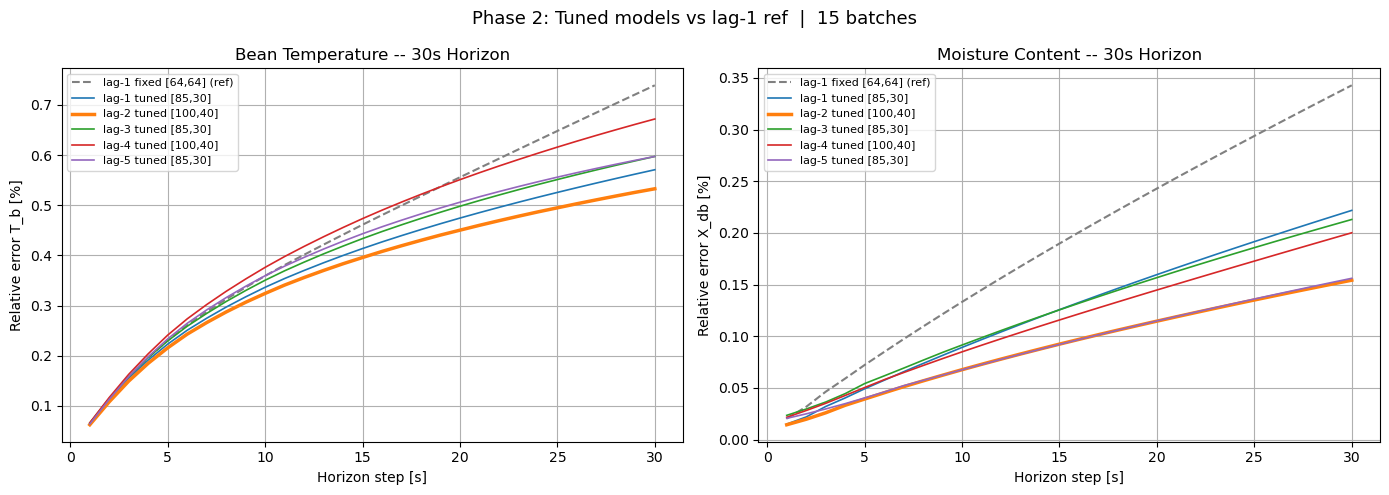

In [16]:
steps = np.arange(1, HORIZON_STEPS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Lag-1 fixed as dashed gray reference
ref_agg = phase1_results[1]['_mpc_agg']
axes[0].plot(steps, np.mean(ref_agg['horizon_rel_Tb'], axis=0),
             label='lag-1 fixed [64,64] (ref)', linestyle='--', color='gray', linewidth=1.5)
axes[1].plot(steps, np.mean(ref_agg['horizon_rel_X'],  axis=0),
             label='lag-1 fixed [64,64] (ref)', linestyle='--', color='gray', linewidth=1.5)

colors = plt.cm.tab10.colors
for i, lag in enumerate(LAG_DEPTHS_TO_TEST):
    agg   = phase2_results[lag]['_mpc_agg']
    arch  = phase2_results[lag]['architecture']
    label = f'lag-{lag} tuned {arch}'
    lw    = 2.5 if lag == winner_lag else 1.2
    axes[0].plot(steps, np.mean(agg['horizon_rel_Tb'], axis=0),
                 label=label, color=colors[i], linewidth=lw)
    axes[1].plot(steps, np.mean(agg['horizon_rel_X'],  axis=0),
                 label=label, color=colors[i], linewidth=lw)

for ax, ylabel, title in zip(axes,
    ['Relative error T_b [%]', 'Relative error X_db [%]'],
    ['Bean Temperature -- 30s Horizon', 'Moisture Content -- 30s Horizon']):
    ax.set_xlabel('Horizon step [s]')
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend(fontsize=8); ax.grid(True)

plt.suptitle(
    f'Phase 2: Tuned models vs lag-1 ref  |  {N_BATCHES_SAMPLE} batches',
    fontsize=13)
plt.tight_layout()
plt.show()


## 17. Save all results

**Where data is saved:** `SAVE_DIR` is set in Cell 3 (configuration).

**Before each run, change two things in Cell 3:**
1. `N_BATCHES_SAMPLE` to 5, 10, or 15
2. `SAVE_DIR` to `./results_5batches`, `./results_10batches`, or `./results_15batches`

**Files saved per run:**
- `full_comparison_table.csv` — the main Phase 3 table
- `optuna_trials_lag{N}.csv` — Optuna trial details for each lag
- `final_model_lag{N}.pt` — weights for each tuned model
- `model_config_lag{N}.json` — architecture + hyperparams to reload each model
- `x_scaler_lag{N}.pkl` / `y_scaler_lag{N}.pkl` — scalers per lag


In [17]:
SAVE_DIR.mkdir(parents=True, exist_ok=True)

df_full.to_csv(SAVE_DIR / 'full_comparison_table.csv')
print('Saved: full_comparison_table.csv')

for lag in LAG_DEPTHS_TO_TEST:
    r = phase2_results[lag]

    # Optuna trials
    study = r['_study']
    study.trials_dataframe().sort_values('value').to_csv(
        SAVE_DIR / f'optuna_trials_lag{lag}.csv', index=False)

    # Model weights
    torch.save(r['_model'].state_dict(), SAVE_DIR / f'final_model_lag{lag}.pt')

    # Config (needed to rebuild the model for inference)
    config = {
        'n_lags': lag, 'input_dim': r['input_dim'],
        'hidden1': r['hidden1'], 'hidden2': r['hidden2'], 'output_dim': 2,
        'lr': r['lr'], 'weight_decay': r['weight_decay'],
        'T_B_RANGE': T_B_RANGE, 'X_DB_RANGE': X_DB_RANGE,
        'horizon_steps': HORIZON_STEPS,
        'n_batches': N_BATCHES_SAMPLE, 'batch_seed': BATCH_SEED,
    }
    with open(SAVE_DIR / f'model_config_lag{lag}.json', 'w') as f:
        json.dump(config, f, indent=2)

    # Scalers
    with open(SAVE_DIR / f'x_scaler_lag{lag}.pkl', 'wb') as f:
        pickle.dump(r['_x_sc'], f)
    with open(SAVE_DIR / f'y_scaler_lag{lag}.pkl', 'wb') as f:
        pickle.dump(r['_y_sc'], f)

    print(f"Saved: lag-{lag}  {r['architecture']}")

print(f'\nAll results saved to: {SAVE_DIR.resolve()}')
print('Contents:', sorted([p.name for p in SAVE_DIR.iterdir()]))


Saved: full_comparison_table.csv
Saved: lag-1  [85,30]
Saved: lag-2  [100,40]
Saved: lag-3  [85,30]
Saved: lag-4  [100,40]
Saved: lag-5  [85,30]

All results saved to: /home/ma-stud/Downloads/Python example files/results_15batches
Contents: ['final_model_lag1.pt', 'final_model_lag2.pt', 'final_model_lag3.pt', 'final_model_lag4.pt', 'final_model_lag5.pt', 'full_comparison_table.csv', 'model_config_lag1.json', 'model_config_lag2.json', 'model_config_lag3.json', 'model_config_lag4.json', 'model_config_lag5.json', 'optuna_trials_lag1.csv', 'optuna_trials_lag2.csv', 'optuna_trials_lag3.csv', 'optuna_trials_lag4.csv', 'optuna_trials_lag5.csv', 'x_scaler_lag1.pkl', 'x_scaler_lag2.pkl', 'x_scaler_lag3.pkl', 'x_scaler_lag4.pkl', 'x_scaler_lag5.pkl', 'y_scaler_lag1.pkl', 'y_scaler_lag2.pkl', 'y_scaler_lag3.pkl', 'y_scaler_lag4.pkl', 'y_scaler_lag5.pkl']
